In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/hospital_readmissions.csv")

In [3]:
df.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


In [4]:
df.shape

(25000, 17)

In [5]:
df.columns

Index(['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures',
       'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency',
       'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test',
       'A1Ctest', 'change', 'diabetes_med', 'readmitted'],
      dtype='object')

In [6]:
df.dtypes

age                  object
time_in_hospital      int64
n_lab_procedures      int64
n_procedures          int64
n_medications         int64
n_outpatient          int64
n_inpatient           int64
n_emergency           int64
medical_specialty    object
diag_1               object
diag_2               object
diag_3               object
glucose_test         object
A1Ctest              object
change               object
diabetes_med         object
readmitted           object
dtype: object

In [7]:
df.isnull().sum()

age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64

In [8]:
df["readmitted"].value_counts()

readmitted
no     13246
yes    11754
Name: count, dtype: int64

# Hospital Readmission Analysis

## Project Objective

This project investigates factors associated with hospital readmission using patient and hospital data.

## Initial Hypotheses

1. I hypothesise that older patients may have a higher rate of hospital readmission.

2. I hypothesise that patients with longer hospital stays may have a higher rate of readmission.

3. I hypothesise that patients with a greater number of previous hospital encounters may have a higher rate of readmission.

# Data Cleaning

In [9]:
df.isnull().sum()

age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64

In [10]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["readmitted"].value_counts()

readmitted
no     13246
yes    11754
Name: count, dtype: int64

In [13]:
df["change"].value_counts()

change
no     13497
yes    11503
Name: count, dtype: int64

In [14]:
df["diabetes_med"].value_counts()

diabetes_med
yes    19228
no      5772
Name: count, dtype: int64

In [15]:
df["glucose_test"].value_counts()

glucose_test
no        23625
normal      689
high        686
Name: count, dtype: int64

In [16]:
df["A1Ctest"].value_counts()

A1Ctest
no        20938
high       2827
normal     1235
Name: count, dtype: int64

In [17]:
df["medical_specialty"].value_counts()

medical_specialty
Missing                   12382
InternalMedicine           3565
Other                      2664
Emergency/Trauma           1885
Family/GeneralPractice     1882
Cardiology                 1409
Surgery                    1213
Name: count, dtype: int64

In [18]:
df["medical_specialty"].value_counts(normalize=True) * 100

medical_specialty
Missing                   49.528
InternalMedicine          14.260
Other                     10.656
Emergency/Trauma           7.540
Family/GeneralPractice     7.528
Cardiology                 5.636
Surgery                    4.852
Name: proportion, dtype: float64

In [19]:
df.describe()

,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency
count,25000.00000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,4.45332,43.24076,1.352360,16.252400,0.366400,0.615960,0.186600
std,3.00147,19.81862,1.715179,8.060532,1.195478,1.177951,0.885873
min,1.00000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2.00000,31.00000,0.000000,11.000000,0.000000,0.000000,0.000000
50%,4.00000,44.00000,1.000000,15.000000,0.000000,0.000000,0.000000
75%,6.00000,57.00000,2.000000,20.000000,0.000000,1.000000,0.000000
max,14.00000,113.00000,6.000000,79.000000,33.000000,15.000000,64.000000


In [20]:
count_columns = [
    "time_in_hospital",
    "n_lab_procedures",
    "n_procedures",
    "n_medications",
    "n_outpatient",
    "n_inpatient",
    "n_emergency"
]

(df[count_columns] < 0).sum()

time_in_hospital    0
n_lab_procedures    0
n_procedures        0
n_medications       0
n_outpatient        0
n_inpatient         0
n_emergency         0
dtype: int64

In [21]:
df.select_dtypes(include="object").nunique()

age                  6
medical_specialty    7
diag_1               8
diag_2               8
diag_3               8
glucose_test         3
A1Ctest              3
change               2
diabetes_med         2
readmitted           2
dtype: int64

In [22]:
df_clean = df.copy()

In [23]:
df_clean.shape

(25000, 17)

## Data Cleaning Decisions

The dataset was checked for missing values, duplicate records, invalid categorical values, and impossible negative values.

- No null (`NaN`) values were identified.
- No duplicate rows were identified.
- Categorical variables contained expected values.
- No negative values were found in the count-based numerical variables.
- The `medical_specialty` column contains `"Missing"` for approximately 49.5% of records. These records were retained rather than removed because deleting them would remove a substantial proportion of the dataset.
- No rows were removed during cleaning.

In [24]:
df_clean.to_csv("data/hospital_readmissions_clean.csv", index=False)

In [25]:
import os

os.listdir("data")

['.DS_Store',
 'hospital_readmissions_clean.csv',
 '.ipynb_checkpoints',
 'hospital_readmissions.csv']

# Exploratory Data Analysis

In this section, I will explore patterns in hospital readmissions and examine how patient characteristics and prior healthcare use may relate to readmission.

In [26]:
df_clean["readmitted"].value_counts()

readmitted
no     13246
yes    11754
Name: count, dtype: int64

In [27]:
df_clean["readmitted"].value_counts(normalize=True).mul(100).round(1)

readmitted
no     53.0
yes    47.0
Name: proportion, dtype: float64

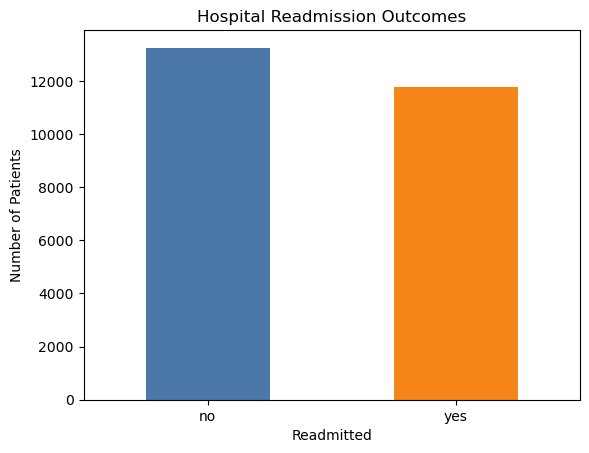

In [28]:
import matplotlib.pyplot as plt

df_clean["readmitted"].value_counts().plot(
    kind="bar",
    color=["#4C78A8", "#F58518"]
)

plt.title("Hospital Readmission Outcomes")
plt.xlabel("Readmitted")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

In [29]:
age_readmission = pd.crosstab(
    df_clean["age"],
    df_clean["readmitted"],
    normalize="index"
) * 100

age_readmission.round(1)

readmitted,no,yes
age,,
[40-50),55.5,44.5
[50-60),55.8,44.2
[60-70),53.2,46.8
[70-80),51.2,48.8
[80-90),50.4,49.6
[90-100),57.9,42.1


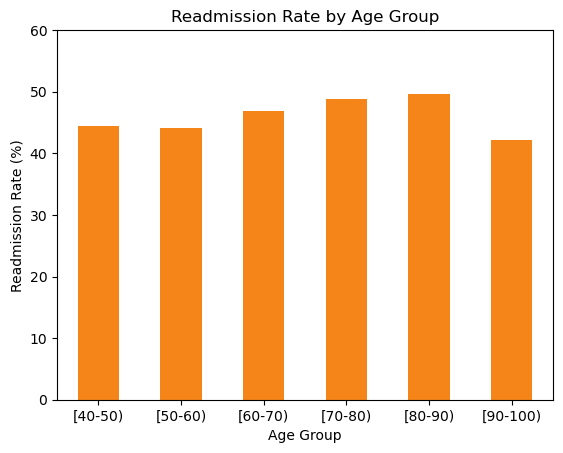

In [30]:
age_readmission["yes"].plot(
    kind="bar",
    color="#F58518"
)

plt.title("Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 60)
plt.show()

In [31]:
df_clean["age"].value_counts().sort_index()

age
[40-50)     2532
[50-60)     4452
[60-70)     5913
[70-80)     6837
[80-90)     4516
[90-100)     750
Name: count, dtype: int64

In [32]:
df_clean.groupby("readmitted")["time_in_hospital"].agg(
    ["count", "mean", "median"]
).round(1)

,count,mean,median
readmitted,,,
no,13246,4.3,4.0
yes,11754,4.6,4.0


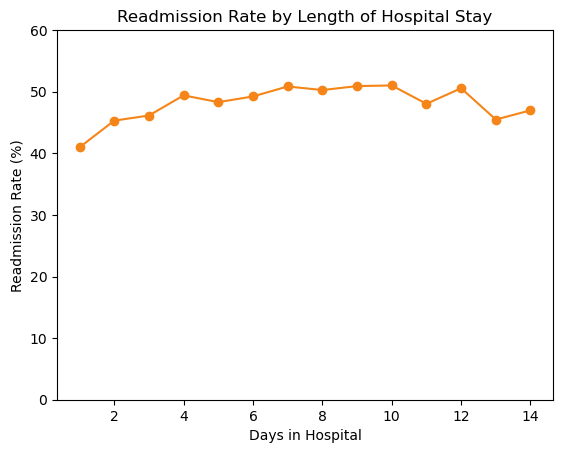

In [33]:
stay_readmission = pd.crosstab(
    df_clean["time_in_hospital"],
    df_clean["readmitted"],
    normalize="index"
) * 100

stay_readmission["yes"].plot(
    kind="line",
    marker="o",
    color="#F58518"
)

plt.title("Readmission Rate by Length of Hospital Stay")
plt.xlabel("Days in Hospital")
plt.ylabel("Readmission Rate (%)")
plt.ylim(0, 60)
plt.show()

In [34]:
inpatient_readmission = pd.crosstab(
    df_clean["n_inpatient"],
    df_clean["readmitted"],
    normalize="index"
) * 100

inpatient_readmission["yes"].round(1)

n_inpatient
0      39.9
1      54.7
2      64.6
3      70.3
4      76.3
5      81.0
6      90.4
7      85.1
8      92.3
9      85.0
10     91.7
11    100.0
12    100.0
13     50.0
14    100.0
15    100.0
Name: yes, dtype: float64

In [35]:
df_clean["n_inpatient"].value_counts().sort_index()

n_inpatient
0     16537
1      4926
2      1909
3       833
4       358
5       211
6       104
7        47
8        26
9        20
10       12
11        8
12        3
13        2
14        2
15        2
Name: count, dtype: int64

In [36]:
prior_inpatient_group = df_clean["n_inpatient"].apply(
    lambda visits: "One or more prior visits" if visits > 0 else "No prior visits"
)

prior_inpatient_summary = pd.crosstab(
    prior_inpatient_group,
    df_clean["readmitted"],
    normalize="index"
) * 100

prior_inpatient_summary.round(1)

readmitted,no,yes
n_inpatient,,
No prior visits,60.1,39.9
One or more prior visits,39.0,61.0


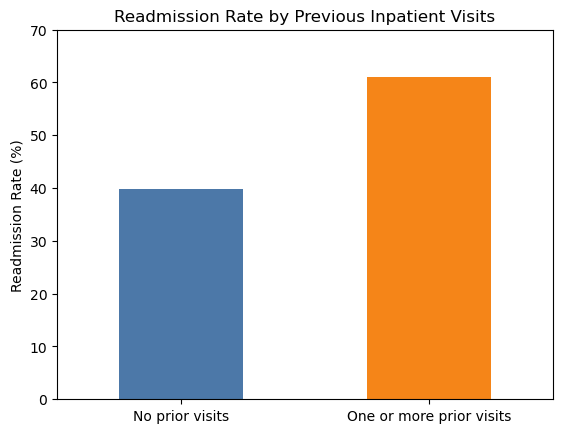

In [37]:
prior_inpatient_summary["yes"].plot(
    kind="bar",
    color=["#4C78A8", "#F58518"]
)

plt.title("Readmission Rate by Previous Inpatient Visits")
plt.xlabel("")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 70)
plt.show()

In [38]:
emergency_group = df_clean["n_emergency"].apply(
    lambda visits: "One or more prior visits" if visits > 0 else "No prior visits"
)

emergency_summary = pd.crosstab(
    emergency_group,
    df_clean["readmitted"],
    normalize="index"
) * 100

emergency_summary.round(1)

readmitted,no,yes
n_emergency,,
No prior visits,54.9,45.1
One or more prior visits,37.1,62.9


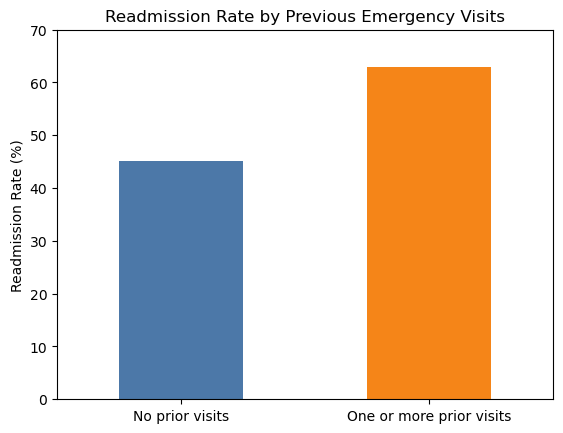

In [39]:
emergency_summary["yes"].plot(
    kind="bar",
    color=["#4C78A8", "#F58518"]
)

plt.title("Readmission Rate by Previous Emergency Visits")
plt.xlabel("")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 70)
plt.show()

In [40]:
outpatient_group = df_clean["n_outpatient"].apply(
    lambda visits: "One or more prior visits" if visits > 0 else "No prior visits"
)

outpatient_summary = pd.crosstab(
    outpatient_group,
    df_clean["readmitted"],
    normalize="index"
) * 100

outpatient_summary.round(1)

readmitted,no,yes
n_outpatient,,
No prior visits,55.6,44.4
One or more prior visits,39.8,60.2


In [41]:
df_clean.groupby("readmitted")[
    ["n_medications", "n_lab_procedures", "n_procedures"]
].mean().round(1)

,n_medications,n_lab_procedures,n_procedures
readmitted,,,
no,16.0,42.6,1.4
yes,16.6,43.9,1.3


In [42]:
diabetes_med_readmission = pd.crosstab(
    df_clean["diabetes_med"],
    df_clean["readmitted"],
    normalize="index"
) * 100

diabetes_med_readmission.round(1)

readmitted,no,yes
diabetes_med,,
no,58.6,41.4
yes,51.3,48.7


In [43]:
medication_change_readmission = pd.crosstab(
    df_clean["change"],
    df_clean["readmitted"],
    normalize="index"
) * 100

medication_change_readmission.round(1)

readmitted,no,yes
change,,
no,55.0,45.0
yes,50.6,49.4


## Key Findings

- Overall, 47.0% of patients in the dataset were readmitted.
- Readmission rates were slightly higher for patients aged 70–90, although the 90–100 age group was much smaller and should be interpreted cautiously.
- Patients who were readmitted had slightly longer hospital stays on average (4.6 days compared with 4.3 days).
- Previous healthcare use showed the strongest associations with readmission:
  - Patients with one or more previous inpatient visits had a 61.0% readmission rate, compared with 39.9% for patients with no previous inpatient visits.
  - Patients with one or more previous emergency visits had a 62.9% readmission rate, compared with 45.1% for patients with no previous emergency visits.
  - Patients with one or more previous outpatient visits had a 60.2% readmission rate, compared with 44.4% for patients with no previous outpatient visits.
- Patients receiving diabetes medication and patients whose medication changed during their stay also had slightly higher readmission rates.

These results show associations only and do not prove that any individual factor causes readmission.

## SQL Analysis

This section uses SQL queries to investigate patterns in hospital readmissions.

In [44]:
import sqlite3

conn = sqlite3.connect(":memory:")

df_clean.to_sql(
    "hospital_readmissions",
    conn,
    index=False,
    if_exists="replace"
)

25000

In [45]:
pd.read_sql_query("""
    SELECT
        readmitted,
        COUNT(*) AS patient_count,
        ROUND(
            COUNT(*) * 100.0 /
            (SELECT COUNT(*) FROM hospital_readmissions),
            1
        ) AS percentage
    FROM hospital_readmissions
    GROUP BY readmitted
    ORDER BY patient_count DESC;
""", conn)

,readmitted,patient_count,percentage
0,no,13246,53.0
1,yes,11754,47.0


In [46]:
pd.read_sql_query("""
    SELECT
        age,
        COUNT(*) AS patient_count,
        SUM(CASE WHEN readmitted = 'yes' THEN 1 ELSE 0 END) AS readmitted_patients,
        ROUND(
            100.0 * SUM(CASE WHEN readmitted = 'yes' THEN 1 ELSE 0 END)
            / COUNT(*),
            1
        ) AS readmission_rate
    FROM hospital_readmissions
    GROUP BY age
    ORDER BY age;
""", conn)

,age,patient_count,readmitted_patients,readmission_rate
0,[40-50),2532,1127,44.5
1,[50-60),4452,1966,44.2
2,[60-70),5913,2770,46.8
3,[70-80),6837,3336,48.8
4,[80-90),4516,2239,49.6
5,[90-100),750,316,42.1


In [47]:
pd.read_sql_query("""
    SELECT
        CASE
            WHEN n_inpatient = 0 THEN 'No prior inpatient visits'
            ELSE 'One or more prior inpatient visits'
        END AS prior_inpatient_visits,
        COUNT(*) AS patient_count,
        ROUND(
            100.0 * SUM(CASE WHEN readmitted = 'yes' THEN 1 ELSE 0 END)
            / COUNT(*),
            1
        ) AS readmission_rate
    FROM hospital_readmissions
    GROUP BY
        CASE
            WHEN n_inpatient = 0 THEN 'No prior inpatient visits'
            ELSE 'One or more prior inpatient visits'
        END
    ORDER BY patient_count DESC;
""", conn)

,prior_inpatient_visits,patient_count,readmission_rate
0,No prior inpatient visits,16537,39.9
1,One or more prior inpatient visits,8463,61.0


In [48]:
pd.read_sql_query("""
    SELECT
        n_inpatient AS previous_inpatient_visits,
        COUNT(*) AS patient_count,
        ROUND(
            100.0 * SUM(CASE WHEN readmitted = 'yes' THEN 1 ELSE 0 END)
            / COUNT(*),
            1
        ) AS readmission_rate
    FROM hospital_readmissions
    WHERE n_inpatient <= 4
    GROUP BY n_inpatient
    ORDER BY n_inpatient;
""", conn)

,previous_inpatient_visits,patient_count,readmission_rate
0,0,16537,39.9
1,1,4926,54.7
2,2,1909,64.6
3,3,833,70.3
4,4,358,76.3


### SQL Analysis Summary

SQL queries were used to calculate readmission counts and rates across patient groups.

- The dataset contains 25,000 patients, with an overall readmission rate of 47.0%.
- Readmission rates increased across the 40–90 age groups, from 44.5% to 49.6%. The 90–100 group was smaller and should be interpreted cautiously.
- Previous inpatient visits were strongly associated with readmission. The readmission rate increased from 39.9% for patients with no previous inpatient visits to 76.3% for those with four.
- These findings describe associations and do not establish causation.